In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [28]:
df = pd.read_csv("Mental_Health_Lifestyle_Dataset.csv")

In [29]:
df.head()

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      3000 non-null   object 
 1   Age                          3000 non-null   int64  
 2   Gender                       3000 non-null   object 
 3   Exercise Level               3000 non-null   object 
 4   Diet Type                    3000 non-null   object 
 5   Sleep Hours                  3000 non-null   float64
 6   Stress Level                 3000 non-null   object 
 7   Mental Health Condition      2405 non-null   object 
 8   Work Hours per Week          3000 non-null   int64  
 9   Screen Time per Day (Hours)  3000 non-null   float64
 10  Social Interaction Score     3000 non-null   float64
 11  Happiness Score              3000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 281.4+ KB


In [31]:
df.describe()

,Age,Sleep Hours,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,41.229667,6.475933,39.466333,5.089833,5.470200,5.395067
std,13.428416,1.499866,11.451459,1.747231,2.563532,2.557601
min,18.000000,1.400000,20.000000,2.000000,1.000000,1.000000
25%,30.000000,5.500000,30.000000,3.600000,3.300000,3.200000
50%,41.000000,6.500000,39.000000,5.100000,5.500000,5.400000
75%,53.000000,7.500000,50.000000,6.600000,7.600000,7.500000
max,64.000000,11.300000,59.000000,8.000000,10.000000,10.000000


In [32]:
df.isnull().sum()

Country                          0
Age                              0
Gender                           0
Exercise Level                   0
Diet Type                        0
Sleep Hours                      0
Stress Level                     0
Mental Health Condition        595
Work Hours per Week              0
Screen Time per Day (Hours)      0
Social Interaction Score         0
Happiness Score                  0
dtype: int64

# Countries by Average Happiness Score

In [33]:
#Group by country and calculate average happiness score
country_happiness = df.groupby('Country')['Happiness Score'].mean()

#Sort from highest to lowest
country_happiness = country_happiness.sort_values(ascending=False)

#Result
print(country_happiness)

Country
Canada       5.559112
Australia    5.494240
India        5.378802
Germany      5.368069
USA          5.350448
Brazil       5.335904
Japan        5.279271
Name: Happiness Score, dtype: float64


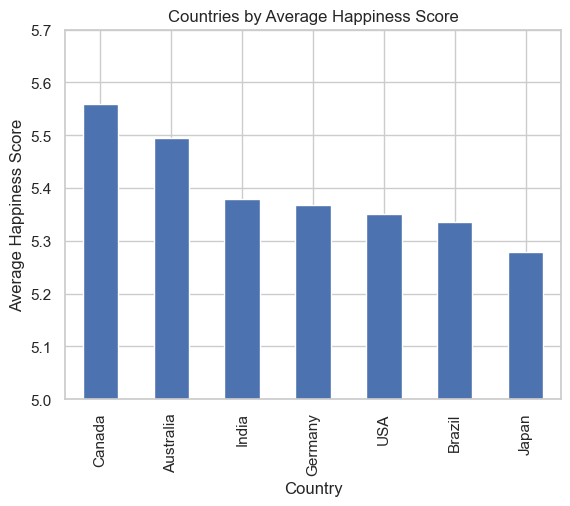

In [34]:
country_happiness.head(10).plot(kind='bar')
plt.title('Countries by Average Happiness Score')
plt.ylabel('Average Happiness Score')
plt.ylim(5.0, 5.7) #zooming in results
plt.show()

# Basic Cleaning

In [35]:
df_clean = df.copy()
label_cols = ['Gender', 'Exercise Level', 'Diet Type', 'Stress Level', 'Mental Health Condition']
le = LabelEncoder()

for col in label_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean.head()

,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,1,1,4,6.3,1,4,21,4.0,7.8,6.5
1,Australia,31,1,2,3,4.9,1,3,48,5.2,8.2,6.8
2,Japan,37,0,1,4,7.2,0,4,43,4.7,9.6,9.7
3,Brazil,35,1,1,3,7.2,1,2,43,2.2,8.2,6.6
4,Germany,46,1,1,0,7.3,1,0,35,3.6,4.7,4.4


# Happiness Score

In [36]:
#Features (predictors/inputs) - Exogenous - Explanatory Variable
X = df_clean.drop(columns=['Happiness Score', 'Country'])

#Target (Outcome/what we predict) - Endogenous - Response Variable
y = df_clean['Happiness Score']

# Train/Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Model (Random Forest)

In [38]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test)

#Evaluate
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 6.981176104999999
R2 Score: -0.031292792225460664


Social Interaction Score       0.163727
Sleep Hours                    0.160392
Screen Time per Day (Hours)    0.154836
Work Hours per Week            0.148966
Age                            0.141438
Mental Health Condition        0.060041
Diet Type                      0.055750
Stress Level                   0.039553
Gender                         0.038678
Exercise Level                 0.036618
dtype: float64


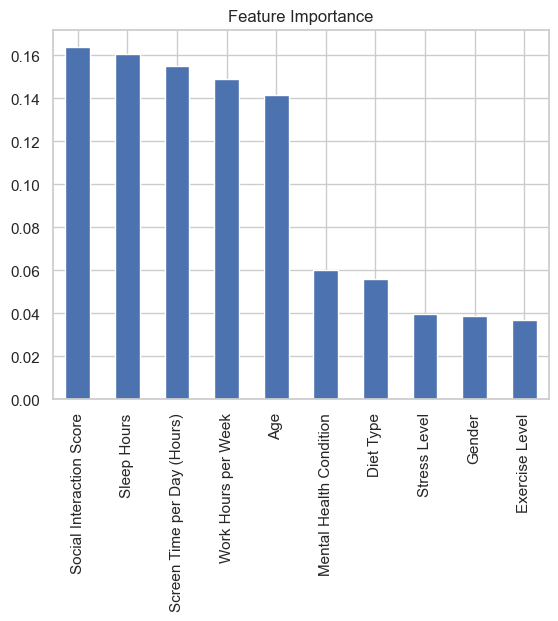

In [40]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

#Plot
plt.figure()
importances.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Categorical variables such as gender, diet type, and mental health condition were included because they allow
the model to differentiate between groups. Although these variables are not inherently numeric, they can still
contribute to predictive performance by capturing group-level differences.

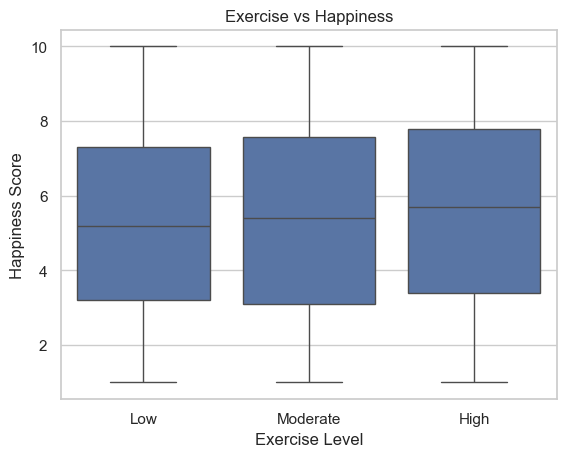

In [41]:
sns.boxplot(x='Exercise Level', y='Happiness Score', data=df)
plt.title("Exercise vs Happiness")
plt.show()

The boxplot suggests a slight positive relationship between exercise level and happiness score. Individuals
with higher levels of exercise tend to have marginally higher median happiness scores, although there is
considerable overlap between groups. This indicates that while exercise may be associated with increased
happiness, it is not the sole determining factor.

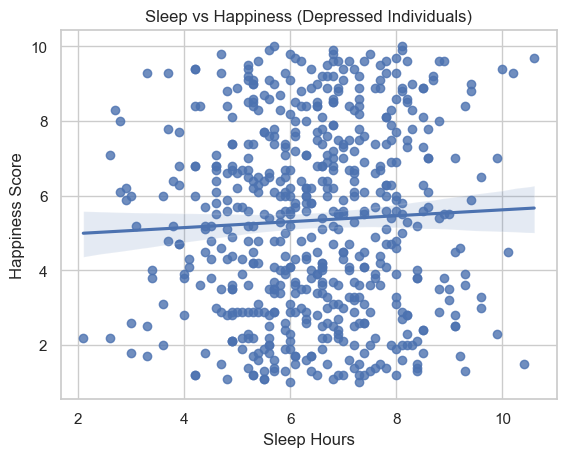

In [42]:
df_dep = df[df['Mental Health Condition'] == 'Depression']

sns.regplot(
    x='Sleep Hours',
    y='Happiness Score',
    data=df_dep)

plt.title("Sleep vs Happiness (Depressed Individuals)")
plt.show()

The scatter plot shows a weak relationship between sleep hours and happiness score among individuals
with depression. The data points are widely dispersed, indicating that both low and high levels of sleep
are associated with a broad range of happiness scores. While there may be a slight positive trend, the
relationship is not strong, suggesting that sleep alone is not a reliable predictor of happiness in this group.

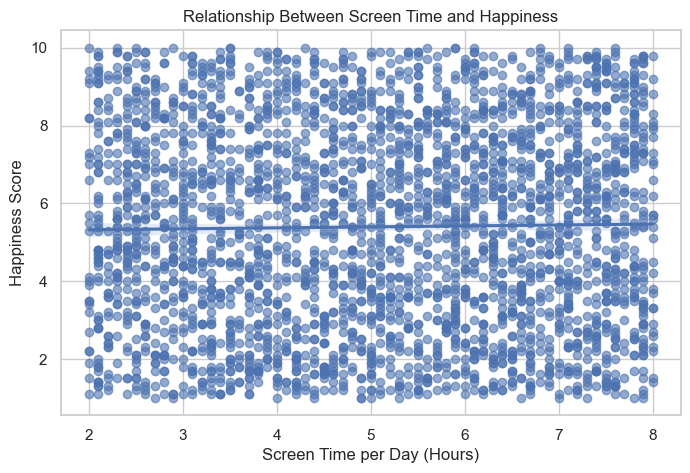

In [43]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Screen Time per Day (Hours)',
    y='Happiness Score',
    data=df_clean,
    scatter_kws={'alpha':0.6})

plt.title('Relationship Between Screen Time and Happiness')
plt.xlabel('Screen Time per Day (Hours)')
plt.ylabel('Happiness Score')
plt.show()

The scatter plot shows no clear replationship between screen time and happiness score. The data points are
widely dispersed across all levels of screen time, and the regression line appears nearly flat, indicating 
little to no linear correlation between the two variables. Individuals with both low and high screen time
exhibit a broad range of happiness levels. This suggests that screen time alone is not a strong predictor
of mental well-being in this dataset, and other factors are likely more influential in determining happiness.

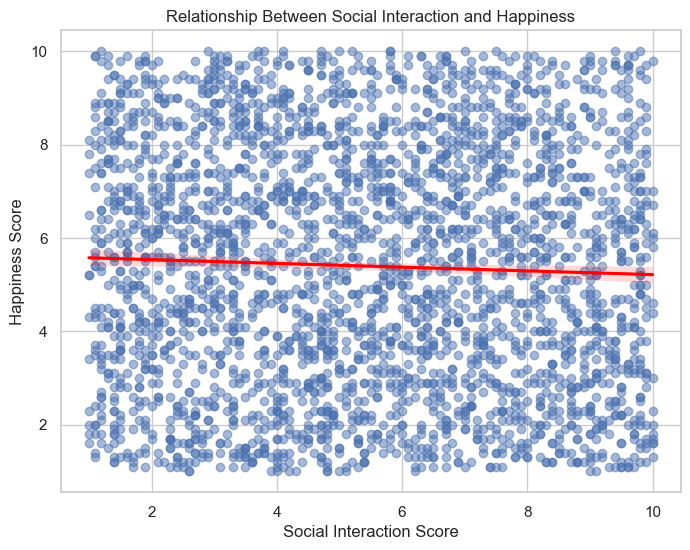

In [44]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='Social Interaction Score',
    y='Happiness Score',
    data=df_clean,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'})

plt.title('Relationship Between Social Interaction and Happiness')
plt.xlabel('Social Interaction Score')
plt.ylabel('Happiness Score')

plt.show()

The scatter plot shows no strong relationship between social interaction score and happiness. While the
regression line has a slight negative slope, the data points are widely dispersed, indicating a very 
weak correlation. This suggests that, within this dataset, social interaction does not significantly
predict happiness levels.

In [45]:
X = df_clean[['Exercise Level', 'Sleep Hours', 'Screen Time per Day (Hours)', 'Social Interaction Score']]
y = df_clean['Happiness Score']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness Score   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.312
Date:                Fri, 24 Apr 2026   Prob (F-statistic):             0.0554
Time:                        20:14:04   Log-Likelihood:                -7068.9
No. Observations:                3000   AIC:                         1.415e+04
Df Residuals:                    2995   BIC:                         1.418e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

A multiple linear regression analysis was conducted to examine whether exercise level, sleep duration,
screen time, and social interaction predict happiness scores. This suggests that, within this dataset,
these lifestyle factors do not meaningfully influence happiness, or that the data may lack underlying
structure.

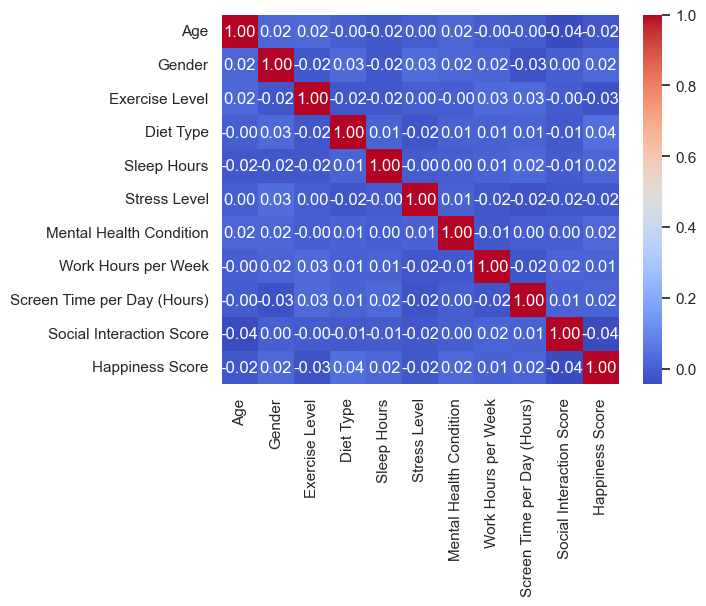

In [46]:
numeric_df = df_clean.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt=".2f",
            cmap='coolwarm')
plt.show()

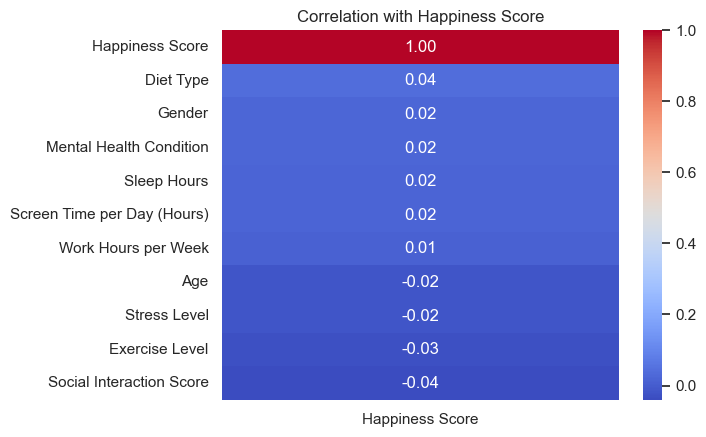

In [47]:
corr = numeric_df.corr()[['Happiness Score']].sort_values(by='Happiness Score', ascending=False)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

plt.title("Correlation with Happiness Score")
plt.show()